In [1]:
import pandas as pd
import statsmodels.api as sm

# 1. Force the file path verification right inside the cell
import os
print(f"Current Directory: {os.getcwd()}")
print(f"Files Python can see: {os.listdir('.')}")

try:
    # 2. Re-read the fresh data file
    raw_data = pd.read_csv('1.03.+Dummies.csv')
    data = raw_data.copy()
    data['Attendance'] = data['Attendance'].map({'Yes': 1, 'No': 0})
    
    # 3. Re-scramble the deck to fix autocorrelation
    data_shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # 4. Declare your clean target and multi-variables
    y = data_shuffled['GPA']
    x1 = data_shuffled[['SAT', 'Attendance']]
    
    # 5. Add the structural constant baseline
    x = sm.add_constant(x1)
    results = sm.OLS(y, x).fit()
    print("--- SUCCESS: Variables loaded into active RAM memory! ---")
    
except Exception as e:
    print(f"🛑 SYSTEM BLOCKED AT STARTUP: {e}")
    print("Verify that '1.03.+Dummies.csv' is sitting in the file list printed above!")

Current Directory: C:\Users\Waheed\Desktop\AI stuff\stats-and-ai-learning
Files Python can see: ['.git', '.gitignore', '.ipynb_checkpoints', '1.01.Simple linear regression.csv', '1.02.+Multiple+linear+regression.csv', '1.03.+Dummies.csv', 'AI Stuff revamped.ipynb', 'anaconda_projects', 'Dummy+Variables.ipynb', 'Dummy+variables_with_comments.ipynb', 'Multiple+linear+regression+and+Adjusted+R-squared_.ipynb', 'Multiple+linear+regression+and+Adjusted+R-squared_with_comments.ipynb', 'Multiple+Linear+Regression+Exercise+Solution.ipynb', 'Multiple+Linear+Regression+Exercise.ipynb', 'Multiple+Linear+Regression+with+Dummies+Exercise+Solution.ipynb', 'Multiple+Linear+Regression+with+Dummies+Exercise.ipynb', 'real_estate_price_size.csv', 'real_estate_price_size_year.csv', 'real_estate_price_size_year_view.csv', 'Simple+Linear+Regression+Exercise+Solution.ipynb', 'Simple+Linear+Regression+Exercise.ipynb', 'Simple+linear+regression.ipynb', 'Simple+linear+regression_with_comments.ipynb', 'Untitled.

In [2]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           2.19e-15
Time:                        01:52:48   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.076      -0.069       1.357
SAT            0.0014      0.000      7.141      0.000       0.001       0.002
Attendance     0.2226      0.041      5.451      0.000       0.141       0.304
==============================================================================
Omnibus:                       19.560   Durbin-Watson:                   2.135
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.189
Skew:                          -1.028   Prob(JB):                     1.25e-06
Kurtosis:                       4.881   Cond. No.                     3.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [4]:
raw_data=pd.read_csv('1.03.+Dummies.csv')

In [5]:
raw_data

,SAT,GPA,Attendance
0,1714,2.40,No
1,1664,2.52,No
2,1760,2.54,No
3,1685,2.74,No
4,1693,2.83,No
...,...,...,...
79,1936,3.71,Yes
80,1810,3.71,Yes
81,1987,3.73,No
82,1962,3.76,Yes


In [6]:
data = raw_data.copy()

In [7]:
data['Attendance'] = data['Attendance'].map({'Yes': 1, 'No': 0})

In [8]:
data

,SAT,GPA,Attendance
0,1714,2.40,0
1,1664,2.52,0
2,1760,2.54,0
3,1685,2.74,0
4,1693,2.83,0
...,...,...,...
79,1936,3.71,1
80,1810,3.71,1
81,1987,3.73,0
82,1962,3.76,1


In [9]:
data.describe()

,SAT,GPA,Attendance
count,84.000000,84.000000,84.000000
mean,1845.273810,3.330238,0.464286
std,104.530661,0.271617,0.501718
min,1634.000000,2.400000,0.000000
25%,1772.000000,3.190000,0.000000
50%,1846.000000,3.380000,0.000000
75%,1934.000000,3.502500,1.000000
max,2050.000000,3.810000,1.000000


In [10]:
## REGRESSION

In [11]:
y = data['GPA']
x1 = data[['SAT', 'Attendance']]

In [12]:
x = sm.add_constant(x1)
results = sm.OLS(y,x).fit()

In [13]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           2.19e-15
Time:                        01:52:50   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.076      -0.069       1.357
SAT            0.0014      0.000      7.141      0.000       0.001       0.002
Attendance     0.2226      0.041      5.451      0.000       0.141       0.304
==============================================================================
Omnibus:                       19.560   Durbin-Watson:                   1.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.189
Skew:                          -1.028   Prob(JB):                     1.25e-06
Kurtosis:                       4.881   Cond. No.                     3.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [14]:
## Doing a shuffle in the table so the table shows the "Yes" and "No's" in a random order rather than the No's at the top and the Yes's at the bottom.
## By doing this I hope my Durbin_Watson shoots up so my model fits the data better

In [15]:
data_shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True)

In [16]:
y = data_shuffled['GPA']
x1 = data_shuffled[['SAT', 'Attendance']]

In [17]:
x = sm.add_constant(x1)
results = sm.OLS(y,x).fit()

In [18]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           2.19e-15
Time:                        01:52:50   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.076      -0.069       1.357
SAT            0.0014      0.000      7.141      0.000       0.001       0.002
Attendance     0.2226      0.041      5.451      0.000       0.141       0.304
==============================================================================
Omnibus:                       19.560   Durbin-Watson:                   2.135
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.189
Skew:                          -1.028   Prob(JB):                     1.25e-06
Kurtosis:                       4.881   Cond. No.                     3.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [19]:
## Saw a jump in Durbin-Watson which makes our model more fitting for the data.

In [20]:
## Next step is to plot the data on the graph with the new categorical dummy values to see how our model looks like.

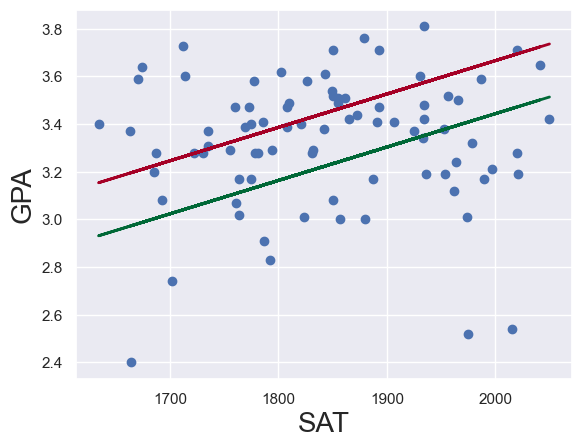

In [21]:
plt.scatter(data['SAT'],y)
yhat_no = 0.6439 + 0.0014*data['SAT']
yhat_yes = 0.8665 + 0.0014*data['SAT']
fig = plt.plot(data['SAT'],yhat_no, lw = 2, c='#006837')
fig = plt.plot(data['SAT'],yhat_yes, lw = 2, c='#a50026')
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

In [22]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     52.70
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           2.19e-15
Time:                        01:52:50   Log-Likelihood:                 25.798
No. Observations:                  84   AIC:                            -45.60
Df Residuals:                      81   BIC:                            -38.30
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6439      0.358      1.797      0.076      -0.069       1.357
SAT            0.0014      0.000      7.141      0.000       0.001       0.002
Attendance     0.2226      0.041      5.451      0.000       0.141       0.304
==============================================================================
Omnibus:                       19.560   Durbin-Watson:                   2.135
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.189
Skew:                          -1.028   Prob(JB):                     1.25e-06
Kurtosis:                       4.881   Cond. No.                     3.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [23]:
## Doing an exercise to see if I understand the concept or not.
## Check the Multiple+Linear+Regression+with+Dummies+Exercise to see the inputs.

In [24]:
# Multiple Linear Regression with Dummies - Exercise

In [25]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [26]:
raw_data = pd.read_csv('real_estate_price_size_year_view.csv')

In [27]:
data = raw_data.copy()

In [28]:
data

,price,size,year,view
0,234314.144,643.09,2015,No sea view
1,228581.528,656.22,2009,No sea view
2,281626.336,487.29,2018,Sea view
3,401255.608,1504.75,2015,No sea view
4,458674.256,1275.46,2009,Sea view
...,...,...,...,...
95,252460.400,549.80,2009,Sea view
96,310522.592,1037.44,2009,No sea view
97,383635.568,1504.75,2006,No sea view
98,225145.248,648.29,2015,No sea view


In [29]:
data['view'] = data['view'].map({'No sea view': 0, 'Sea view': 1})

In [30]:
data

,price,size,year,view
0,234314.144,643.09,2015,0
1,228581.528,656.22,2009,0
2,281626.336,487.29,2018,1
3,401255.608,1504.75,2015,0
4,458674.256,1275.46,2009,1
...,...,...,...,...
95,252460.400,549.80,2009,1
96,310522.592,1037.44,2009,0
97,383635.568,1504.75,2006,0
98,225145.248,648.29,2015,0


In [31]:
data.describe()

,price,size,year,view
count,100.000000,100.000000,100.000000,100.000000
mean,292289.470160,853.024200,2012.600000,0.490000
std,77051.727525,297.941951,4.729021,0.502418
min,154282.128000,479.750000,2006.000000,0.000000
25%,234280.148000,643.330000,2009.000000,0.000000
50%,280590.716000,696.405000,2015.000000,0.000000
75%,335723.696000,1029.322500,2018.000000,1.000000
max,500681.128000,1842.510000,2018.000000,1.000000


In [32]:
## Fixing the NaN bug

In [33]:
data = raw_data.copy()

In [34]:
data['view']=data['view'].map({'No sea view' :0, 'Sea view': 1})

In [35]:
data

,price,size,year,view
0,234314.144,643.09,2015,0
1,228581.528,656.22,2009,0
2,281626.336,487.29,2018,1
3,401255.608,1504.75,2015,0
4,458674.256,1275.46,2009,1
...,...,...,...,...
95,252460.400,549.80,2009,1
96,310522.592,1037.44,2009,0
97,383635.568,1504.75,2006,0
98,225145.248,648.29,2015,0


In [36]:
y = data['price']

In [37]:
x1 = data[['size','year','view']]

In [38]:
x = sm.add_constant(x1)

In [39]:
results = sm.OLS(y,x).fit()

In [40]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     335.2
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           1.02e-50
Time:                        01:52:50   Log-Likelihood:                -1144.6
No. Observations:                 100   AIC:                             2297.
Df Residuals:                      96   BIC:                             2308.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.398e+06   9.94e+05     -5.431      0.000   -7.37e+06   -3.43e+06
size         223.0316      7.838     28.455      0.000     207.473     238.590
year        2718.9489    493.502      5.510      0.000    1739.356    3698.542
view        5.673e+04   4627.695     12.258      0.000    4.75e+04    6.59e+04
==============================================================================
Omnibus:                       29.224   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               64.957
Skew:                           1.088   Prob(JB):                     7.85e-15
Kurtosis:                       6.295   Cond. No.                     9.42e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.42e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [41]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     335.2
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           1.02e-50
Time:                        01:52:50   Log-Likelihood:                -1144.6
No. Observations:                 100   AIC:                             2297.
Df Residuals:                      96   BIC:                             2308.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.398e+06   9.94e+05     -5.431      0.000   -7.37e+06   -3.43e+06
size         223.0316      7.838     28.455      0.000     207.473     238.590
year        2718.9489    493.502      5.510      0.000    1739.356    3698.542
view        5.673e+04   4627.695     12.258      0.000    4.75e+04    6.59e+04
==============================================================================
Omnibus:                       29.224   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               64.957
Skew:                           1.088   Prob(JB):                     7.85e-15
Kurtosis:                       6.295   Cond. No.                     9.42e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.42e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [42]:
## Transitioning into SKlearn toolkit. Starting with Simple linear regression.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import LinearRegression

In [44]:
data = pd.read_csv('1.01.Simple linear regression.csv')
data.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


In [45]:
x = data['SAT']
y = data['GPA']
## GPA = Target, SAT = Feature. (New alternative names for SKlearn only)

In [46]:
x.shape

(84,)

In [47]:
y.shape

(84,)

In [48]:
##Since we got the error down below for trying to reg.fit(x,y) as a 1d array and Sklearn is expecting 2d arrays, we add the following code:

In [49]:
x_matrix= x.values.reshape(-1,1)
x_matrix.shape ## We just change the dimensionality from a 1d object into 2d object

(84, 1)

In [50]:
## Next step is regression.

In [51]:
reg = LinearRegression()

In [52]:
reg.fit(x_matrix,y) ##Input is very important, we always put x first which is the input then y which is the target.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
print(f"The Intercept Baseline: {reg.intercept_}")
print(f"The SAT Multiplier Slope: {reg.coef_}")

The Intercept Baseline: 0.2750402996602781
The SAT Multiplier Slope: [0.00165569]


In [54]:
reg.score(x_matrix,y)

0.40600391479679754

In [55]:
reg.coef_

array([0.00165569])

In [56]:
## Making predictions using SKlearn

In [57]:
reg.predict(1740) ## Will give us the predicted GPA for an SAT score of 1740

ValueError: Expected 2D array, got scalar array instead:
array=1740.
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [60]:
##Fixing the above error into tricking SKlearn that I'm having a 2d array instead of 1d array by using this:
reg.predict([[1740]]) ## By using double brackets the engine will think this is a 2d array instead of 1d.

array([3.15593751])

In [62]:
## Feeding SKlearn a data frame:
new_data=pd.DataFrame(data=[1740,1760], columns=['SAT'])
new_data

,SAT
0,1740
1,1760


In [63]:
reg.predict(new_data)

d:\Users\Waheed\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([3.15593751, 3.18905127])

In [64]:
new_data['Predicted_GPA']= reg.predict(new_data)
new_data

d:\Users\Waheed\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,SAT,Predicted_GPA
0,1740,3.155938
1,1760,3.189051


In [75]:
## Doing the simple linear regression exercise with SKlearn now.

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import LinearRegression

In [77]:
data=pd.read_csv('real_estate_price_size.csv')

In [78]:
data.head()

,price,size
0,234314.144,643.09
1,228581.528,656.22
2,281626.336,487.29
3,401255.608,1504.75
4,458674.256,1275.46


In [79]:
x = data['size']
y = data['price']

In [80]:
x.shape()

TypeError: 'tuple' object is not callable

In [81]:
x.shape

(100,)

In [82]:
y.shape

(100,)

In [83]:
x_matrix = x.values.reshape(-1,1)

In [84]:
x_matrix.shape

(100, 1)

In [85]:
y.shape

(100,)

In [86]:
reg = LinearRegression()

In [87]:
reg.fit(x_matrix,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
reg.coef_

array([223.17874259])

In [89]:
reg.intercept_

np.float64(101912.60180122912)

In [90]:
reg.predict(750)

ValueError: Expected 2D array, got scalar array instead:
array=750.
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [91]:
reg.predict([[750]])

array([269296.65874718])

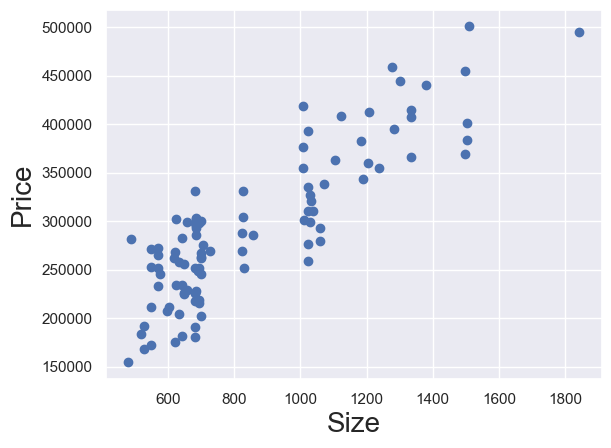

In [92]:
plt.scatter(x,y)
plt.xlabel('Size', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.show()

In [93]:
reg.score()

TypeError: RegressorMixin.score() missing 2 required positional arguments: 'X' and 'y'

In [96]:
reg.score(x_matrix,y) ##Calculating R_Squared

0.7447391865847587

In [95]:
## Exercise ended.

In [97]:
## Multiple linear regression starts.

In [98]:
data = pd.read_csv('1.02.+Multiple+linear+regression.csv')

In [99]:
data.head()

,SAT,"Rand 1,2,3",GPA
0,1714,1,2.40
1,1664,3,2.52
2,1760,3,2.54
3,1685,3,2.74
4,1693,2,2.83


In [101]:
data.describe() ## Rand 1,2,3 is just a random variable assigned to each sample

,SAT,"Rand 1,2,3",GPA
count,84.000000,84.000000,84.000000
mean,1845.273810,2.059524,3.330238
std,104.530661,0.855192,0.271617
min,1634.000000,1.000000,2.400000
25%,1772.000000,1.000000,3.190000
50%,1846.000000,2.000000,3.380000
75%,1934.000000,3.000000,3.502500
max,2050.000000,3.000000,3.810000


In [102]:
x = data [['SAT', 'Rand 1,2,3']]

In [103]:
y = data ['GPA']

In [105]:
reg = LinearRegression()
reg.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [107]:
reg.coef_ ##It responds to the way that we fed it: SAT was first so it spit out 0.00165354, and the Rand 1,2,3 variable is next so it spit out -0.00826982

array([ 0.00165354, -0.00826982])

In [108]:
reg.intercept_

np.float64(0.29603261264909353)

In [109]:
reg.score(x,y)

0.4066811952814282

## Forumula for Adjusted R^2
$R^2_{adj.} = 1 - (1-R^2)*\frac{n-1}{n-p-1}$

In [111]:
## n stands for the number of observations and p stands for the predictors

In [113]:
x.shape ## n = 84 and p = 2

(84, 2)

In [114]:
r2 = reg.score(x,y)

n = x.shape[0]
p = x.shape[1]

adjusted_r2=1-(1-r2)*(n-1)/(n-p-1)
adjusted_r2

0.39203134825134

In [115]:
## Doing the exercise for multiple linear regression adjust r^2 with sklearn

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import LinearRegression

In [117]:
data = pd.read_csv('1.02.+Multiple+linear+regression.csv')

In [118]:
data.head()

,SAT,"Rand 1,2,3",GPA
0,1714,1,2.40
1,1664,3,2.52
2,1760,3,2.54
3,1685,3,2.74
4,1693,2,2.83


In [119]:
data.describe()

,SAT,"Rand 1,2,3",GPA
count,84.000000,84.000000,84.000000
mean,1845.273810,2.059524,3.330238
std,104.530661,0.855192,0.271617
min,1634.000000,1.000000,2.400000
25%,1772.000000,1.000000,3.190000
50%,1846.000000,2.000000,3.380000
75%,1934.000000,3.000000,3.502500
max,2050.000000,3.000000,3.810000


In [120]:
x = data[['SAT', 'Rand 1,2,3']]

In [121]:
y = data['GPA']

In [122]:
reg = LinearRegression()
reg.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [123]:
reg.coef_

array([ 0.00165354, -0.00826982])

In [124]:
reg.intercept_

np.float64(0.29603261264909353)

In [125]:
reg.score(x,y)

0.4066811952814282

In [126]:
x.shape

(84, 2)

In [127]:
r2 = reg.score(x,y)
n = x.shape[0]
p = x.shape[1]

adjusted_r2= 1-(1-r2)*(n-1)/(n-p-1)

In [128]:
adjusted_r2

0.39203134825134

In [129]:
## making it a function to reserve it for future dynamic use:

In [130]:
def adj_r2(x,y):
    r2 = reg.score(x,y)
    n = x.shape[0]
    p = x.shape[1]
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    return adjusted_r2

In [131]:
adj_r2(x,y)

0.39203134825134